In [1]:
# ============================================================
# SafeVision AI — STEP 2
# Environment + Dataset Download
# ============================================================

!nvidia-smi

!pip install -q -U ultralytics==8.3.203

import os
import zipfile
import requests
from pathlib import Path

PROJECT_DIR = Path("/content/safevision_ai")
DATASET_DIR = PROJECT_DIR / "datasets"

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

DATASET_URL = (
    "https://github.com/ultralytics/assets/releases/"
    "download/v0.0.0/construction-ppe.zip"
)

ZIP_PATH = DATASET_DIR / "construction-ppe.zip"

print("=" * 70)
print("SafeVision AI — Environment Setup")
print("=" * 70)

print("\nDownloading Construction-PPE dataset...")

response = requests.get(DATASET_URL, stream=True)
response.raise_for_status()

with open(ZIP_PATH, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)

print(f"✓ Dataset downloaded: {ZIP_PATH}")
print(f"✓ Size: {ZIP_PATH.stat().st_size / (1024**2):.2f} MB")

print("\nExtracting dataset...")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("✓ Dataset extracted")

print("\nDataset structure:")
for path in sorted(DATASET_DIR.iterdir()):
    print(" ", path)

print("\nUltralytics version:")

import ultralytics
print(ultralytics.__version__)

print("\nGPU check:")
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

print("\n" + "=" * 70)
print("STEP 2 COMPLETE")
print("=" * 70)

Thu Sep 10 07:38:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

SafeVision AI — Dataset Analysis

Dataset YAML files found:
[0] /content/safevision_ai/datasets/data.yaml

Using dataset config:
/content/safevision_ai/datasets/data.yaml

Dataset configuration:
{'path': 'construction-ppe', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}, 'download': 'https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip'}

Classes:
0: helmet
1: gloves
2: vest
3: boots
4: goggles
5: none
6: Person
7: no_helmet
8: no_goggle
9: no_gloves
10: no_boots

Total classes: 11

Split paths:
Train: /content/safevision_ai/datasets/images/train
Val  : /content/safevision_ai/datasets/images/val
Test : /content/safevision_ai/datasets/images/test

Image counts:
Train: 1132
Val  : 143
Test : 141
Total: 1416

Analyzing annotations...

Dataset summary:


,Split,Images,Images with Labels,Objects,Invalid Labels
0,Train,1132,1132,9098,0
1,Validation,143,143,1172,0
2,Test,141,141,1251,0



Class distribution:


,Class ID,Class,Train,Validation,Test,Total
0,0,helmet,1341,201,192,1734
1,1,gloves,1146,136,163,1445
2,2,vest,1269,171,178,1618
3,3,boots,1235,151,211,1597
4,4,goggles,419,47,52,518
5,5,none,651,81,65,797
6,6,Person,1770,239,236,2245
7,7,no_helmet,400,45,40,485
8,8,no_goggle,337,41,33,411
9,9,no_gloves,442,56,58,556


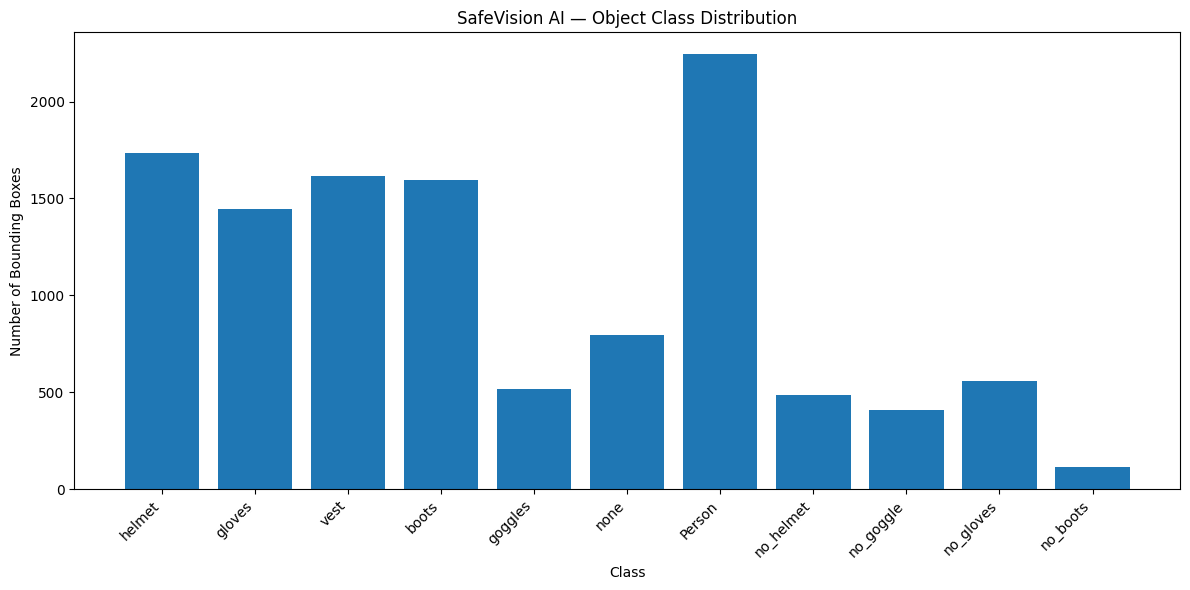

✓ Saved: /content/safevision_ai/class_distribution.png


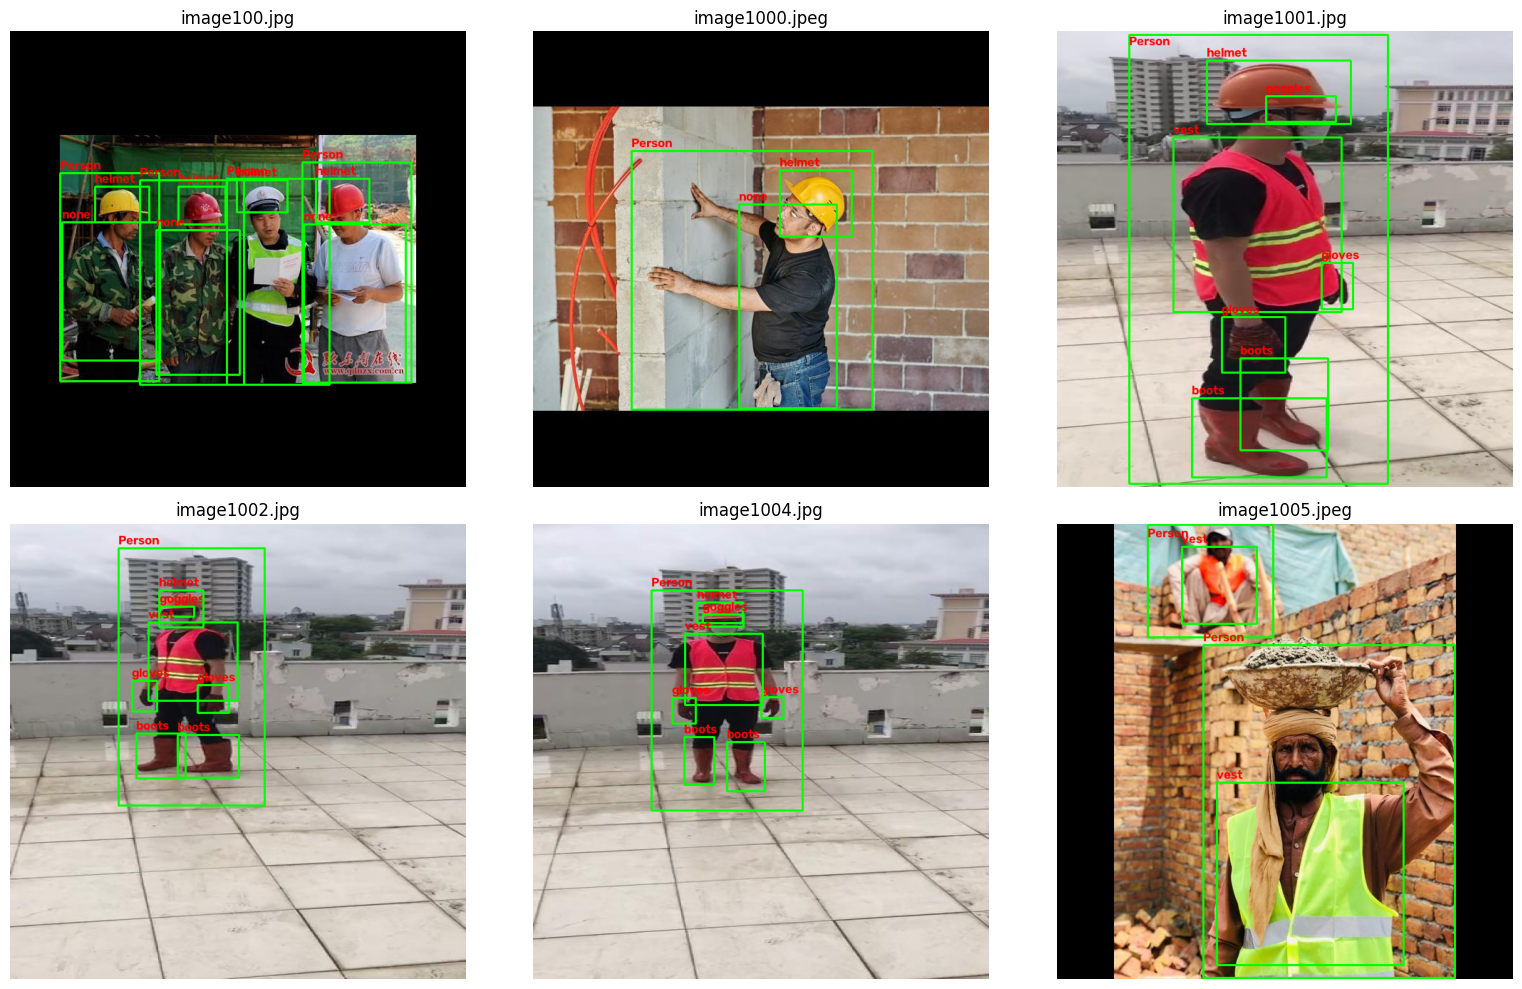

✓ Saved: /content/safevision_ai/dataset_samples.png

Bounding box statistics:


,Normalized Bounding Box Area
count,11521.000000
mean,0.075906
std,0.132831
min,0.000030
25%,0.007172
50%,0.018511
75%,0.072020
max,0.974991


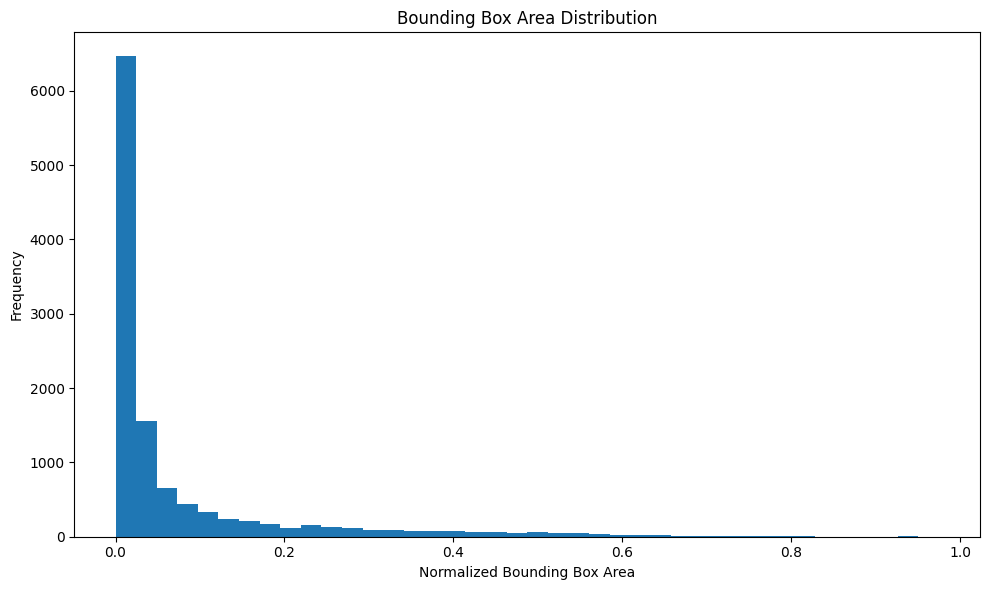

✓ Saved: /content/safevision_ai/bbox_area_distribution.png

DATASET QUALITY CHECK

Total images: 1416
Total annotated objects: 11521
Invalid annotations: 0
✓ No invalid YOLO annotations detected.
✓ All training images have labels.

Class imbalance ratio: 19.52
⚠ Strong class imbalance detected.

STEP 3 COMPLETE


In [2]:
# ============================================================
# SafeVision AI — STEP 3
# Professional Dataset Analysis
# ============================================================

from pathlib import Path
from collections import Counter
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("/content/safevision_ai")
DATASET_DIR = PROJECT_DIR / "datasets"

# ------------------------------------------------------------
# 1. Locate dataset YAML
# ------------------------------------------------------------

yaml_files = list(DATASET_DIR.rglob("*.yaml")) + list(DATASET_DIR.rglob("*.yml"))

print("=" * 70)
print("SafeVision AI — Dataset Analysis")
print("=" * 70)

if not yaml_files:
    raise FileNotFoundError(
        "No dataset YAML file found. Make sure STEP 2 completed successfully."
    )

print("\nDataset YAML files found:")
for i, file in enumerate(yaml_files):
    print(f"[{i}] {file}")

DATA_YAML = yaml_files[0]

print(f"\nUsing dataset config:")
print(DATA_YAML)

# ------------------------------------------------------------
# 2. Read dataset configuration
# ------------------------------------------------------------

with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

print("\nDataset configuration:")
print(data_config)

names = data_config.get("names", {})

if isinstance(names, list):
    class_names = {i: name for i, name in enumerate(names)}
else:
    class_names = {int(k): v for k, v in names.items()}

print("\nClasses:")
for class_id, class_name in class_names.items():
    print(f"{class_id}: {class_name}")

print(f"\nTotal classes: {len(class_names)}")

# ------------------------------------------------------------
# 3. Resolve dataset paths
# ------------------------------------------------------------

dataset_root = DATA_YAML.parent

def resolve_split(split_name):
    value = data_config.get(split_name)

    if value is None:
        return None

    if isinstance(value, list):
        paths = []
        for item in value:
            p = Path(item)
            if not p.is_absolute():
                p = dataset_root / p
            paths.append(p)
        return paths

    p = Path(value)

    if not p.is_absolute():
        p = dataset_root / p

    return p


train_path = resolve_split("train")
val_path = resolve_split("val")
test_path = resolve_split("test")

print("\nSplit paths:")
print("Train:", train_path)
print("Val  :", val_path)
print("Test :", test_path)

# ------------------------------------------------------------
# 4. Find images
# ------------------------------------------------------------

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_images(path):
    if path is None:
        return []

    paths = []

    if isinstance(path, list):
        for p in path:
            if p.is_dir():
                paths.extend(
                    x for x in p.rglob("*")
                    if x.suffix.lower() in IMAGE_EXTENSIONS
                )
            elif p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                paths.append(p)

    elif path.is_dir():
        paths.extend(
            x for x in path.rglob("*")
            if x.suffix.lower() in IMAGE_EXTENSIONS
        )

    elif path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        paths.append(path)

    return sorted(paths)


train_images = collect_images(train_path)
val_images = collect_images(val_path)
test_images = collect_images(test_path)

print("\nImage counts:")
print(f"Train: {len(train_images)}")
print(f"Val  : {len(val_images)}")
print(f"Test : {len(test_images)}")
print(f"Total: {len(train_images) + len(val_images) + len(test_images)}")

# ------------------------------------------------------------
# 5. Find corresponding YOLO labels
# ------------------------------------------------------------

def find_label(image_path):
    """
    Try the standard YOLO dataset structure:
    images/.../file.jpg
    labels/.../file.txt
    """

    parts = list(image_path.parts)

    if "images" in parts:
        idx = len(parts) - 1 - parts[::-1].index("images")
        new_parts = parts[:]
        new_parts[idx] = "labels"

        label_path = Path(*new_parts).with_suffix(".txt")

        if label_path.exists():
            return label_path

    # fallback: search for same filename
    candidates = list(
        image_path.parent.parent.rglob(image_path.stem + ".txt")
    )

    if candidates:
        return candidates[0]

    return None


# ------------------------------------------------------------
# 6. Analyze annotations
# ------------------------------------------------------------

def analyze_split(images):
    class_counter = Counter()
    object_count = 0
    images_with_labels = 0
    images_without_labels = 0
    invalid_labels = 0
    bbox_areas = []

    for image_path in images:

        label_path = find_label(image_path)

        if label_path is None:
            images_without_labels += 1
            continue

        try:
            with open(label_path, "r") as f:
                lines = [line.strip() for line in f if line.strip()]

            if lines:
                images_with_labels += 1

            for line in lines:

                parts = line.split()

                if len(parts) != 5:
                    invalid_labels += 1
                    continue

                class_id = int(parts[0])

                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])

                if class_id not in class_names:
                    invalid_labels += 1
                    continue

                if not (
                    0 <= x_center <= 1
                    and 0 <= y_center <= 1
                    and 0 < width <= 1
                    and 0 < height <= 1
                ):
                    invalid_labels += 1
                    continue

                class_counter[class_id] += 1
                object_count += 1
                bbox_areas.append(width * height)

        except Exception:
            invalid_labels += 1

    return {
        "class_counter": class_counter,
        "object_count": object_count,
        "images_with_labels": images_with_labels,
        "images_without_labels": images_without_labels,
        "invalid_labels": invalid_labels,
        "bbox_areas": bbox_areas,
    }


print("\nAnalyzing annotations...")

train_stats = analyze_split(train_images)
val_stats = analyze_split(val_images)
test_stats = analyze_split(test_images)

# ------------------------------------------------------------
# 7. Dataset statistics table
# ------------------------------------------------------------

split_rows = [
    {
        "Split": "Train",
        "Images": len(train_images),
        "Images with Labels": train_stats["images_with_labels"],
        "Objects": train_stats["object_count"],
        "Invalid Labels": train_stats["invalid_labels"],
    },
    {
        "Split": "Validation",
        "Images": len(val_images),
        "Images with Labels": val_stats["images_with_labels"],
        "Objects": val_stats["object_count"],
        "Invalid Labels": val_stats["invalid_labels"],
    },
    {
        "Split": "Test",
        "Images": len(test_images),
        "Images with Labels": test_stats["images_with_labels"],
        "Objects": test_stats["object_count"],
        "Invalid Labels": test_stats["invalid_labels"],
    },
]

split_df = pd.DataFrame(split_rows)

print("\nDataset summary:")
display(split_df)

# ------------------------------------------------------------
# 8. Class distribution
# ------------------------------------------------------------

total_class_counter = Counter()

for stats in [train_stats, val_stats, test_stats]:
    total_class_counter.update(stats["class_counter"])

class_rows = []

for class_id, class_name in class_names.items():

    train_count = train_stats["class_counter"].get(class_id, 0)
    val_count = val_stats["class_counter"].get(class_id, 0)
    test_count = test_stats["class_counter"].get(class_id, 0)

    class_rows.append({
        "Class ID": class_id,
        "Class": class_name,
        "Train": train_count,
        "Validation": val_count,
        "Test": test_count,
        "Total": train_count + val_count + test_count,
    })

class_df = pd.DataFrame(class_rows)

print("\nClass distribution:")
display(class_df)

# ------------------------------------------------------------
# 9. Class distribution visualization
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    class_df["Class"],
    class_df["Total"]
)

plt.title("SafeVision AI — Object Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Bounding Boxes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

distribution_path = PROJECT_DIR / "class_distribution.png"
plt.savefig(distribution_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Saved: {distribution_path}")

# ------------------------------------------------------------
# 10. Sample images with bounding boxes
# ------------------------------------------------------------

def draw_yolo_boxes(image_path):

    image = cv2.imread(str(image_path))

    if image is None:
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label_path = find_label(image_path)

    if label_path is None:
        return image

    h, w = image.shape[:2]

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:

        parts = line.split()

        if len(parts) != 5:
            continue

        class_id = int(parts[0])

        x_center = float(parts[1])
        y_center = float(parts[2])
        box_width = float(parts[3])
        box_height = float(parts[4])

        x1 = int((x_center - box_width / 2) * w)
        y1 = int((y_center - box_height / 2) * h)
        x2 = int((x_center + box_width / 2) * w)
        y2 = int((y_center + box_height / 2) * h)

        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(0, min(x2, w - 1))
        y2 = max(0, min(y2, h - 1))

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        label = class_names.get(class_id, str(class_id))

        cv2.putText(
            image,
            label,
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    return image


sample_images = train_images[:6]

if sample_images:

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(16, 10)
    )

    for ax, image_path in zip(axes.ravel(), sample_images):

        image = draw_yolo_boxes(image_path)

        if image is not None:
            ax.imshow(image)

        ax.set_title(image_path.name)
        ax.axis("off")

    plt.tight_layout()

    samples_path = PROJECT_DIR / "dataset_samples.png"
    plt.savefig(samples_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"✓ Saved: {samples_path}")

# ------------------------------------------------------------
# 11. Bounding box size analysis
# ------------------------------------------------------------

all_bbox_areas = (
    train_stats["bbox_areas"]
    + val_stats["bbox_areas"]
    + test_stats["bbox_areas"]
)

if all_bbox_areas:

    bbox_area_df = pd.DataFrame({
        "Normalized Bounding Box Area": all_bbox_areas
    })

    print("\nBounding box statistics:")
    display(bbox_area_df.describe())

    plt.figure(figsize=(10, 6))

    plt.hist(
        all_bbox_areas,
        bins=40
    )

    plt.title("Bounding Box Area Distribution")
    plt.xlabel("Normalized Bounding Box Area")
    plt.ylabel("Frequency")

    plt.tight_layout()

    bbox_path = PROJECT_DIR / "bbox_area_distribution.png"
    plt.savefig(bbox_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"✓ Saved: {bbox_path}")

# ------------------------------------------------------------
# 12. Automatic quality observations
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET QUALITY CHECK")
print("=" * 70)

total_images = len(train_images) + len(val_images) + len(test_images)
total_objects = sum(total_class_counter.values())
total_invalid = (
    train_stats["invalid_labels"]
    + val_stats["invalid_labels"]
    + test_stats["invalid_labels"]
)

print(f"\nTotal images: {total_images}")
print(f"Total annotated objects: {total_objects}")
print(f"Invalid annotations: {total_invalid}")

if total_invalid == 0:
    print("✓ No invalid YOLO annotations detected.")
else:
    print("⚠ Invalid annotations detected — investigate before training.")

if train_stats["images_without_labels"] == 0:
    print("✓ All training images have labels.")
else:
    print(
        f"⚠ {train_stats['images_without_labels']} "
        "training images have no labels."
    )

if total_class_counter:

    counts = list(total_class_counter.values())

    min_count = min(counts)
    max_count = max(counts)

    imbalance_ratio = max_count / min_count if min_count > 0 else float("inf")

    print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}")

    if imbalance_ratio >= 10:
        print("⚠ Strong class imbalance detected.")
    elif imbalance_ratio >= 5:
        print("⚠ Moderate class imbalance detected.")
    else:
        print("✓ No severe class imbalance detected.")

print("\n" + "=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

In [3]:
# ============================================================
# SafeVision AI — STEP 4
# YOLO Training
# ============================================================

from pathlib import Path
from ultralytics import YOLO
import torch
import yaml

PROJECT_DIR = Path("/content/safevision_ai")

# Find dataset YAML automatically
yaml_files = list((PROJECT_DIR / "datasets").rglob("*.yaml")) + \
             list((PROJECT_DIR / "datasets").rglob("*.yml"))

if not yaml_files:
    raise FileNotFoundError("Dataset YAML not found.")

DATA_YAML = yaml_files[0]

print("=" * 70)
print("SafeVision AI — YOLO Training")
print("=" * 70)

print(f"\nDataset: {DATA_YAML}")

# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

MODEL_NAME = "yolo11n.pt"

EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 16

PROJECT_NAME = "safevision_training"
RUN_NAME = "yolo11n_ppe"

print("\nTraining configuration:")
print(f"Model      : {MODEL_NAME}")
print(f"Epochs     : {EPOCHS}")
print(f"Image size : {IMAGE_SIZE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Device     : {DEVICE}")

# ------------------------------------------------------------
# Load pretrained YOLO model
# ------------------------------------------------------------

print("\nLoading pretrained YOLO11n...")

model = YOLO(MODEL_NAME)

print("✓ Model loaded")

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("\nStarting training...")
print("=" * 70)

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,

    project=str(PROJECT_DIR / "runs"),
    name=RUN_NAME,

    pretrained=True,

    # Reproducibility
    seed=42,

    # Save best/last checkpoints
    save=True,
    save_period=10,

    # Validation
    val=True,

    # Training optimizations
    patience=12,
    workers=2,

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,

    # Cache images for faster training if possible
    cache=False,

    verbose=True
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(f"\nTraining directory:")
print(PROJECT_DIR / "runs" / RUN_NAME)

print("\nBest model:")
print(PROJECT_DIR / "runs" / RUN_NAME / "weights" / "best.pt")

print("\nLast model:")
print(PROJECT_DIR / "runs" / RUN_NAME / "weights" / "last.pt")

SafeVision AI — YOLO Training

Dataset: /content/safevision_ai/datasets/data.yaml
Device: 0
GPU: Tesla T4

Training configuration:
Model      : yolo11n.pt
Epochs     : 50
Image size : 640
Batch size : 16
Device     : 0

Loading pretrained YOLO11n...
✓ Model loaded

Starting training...
New https://pypi.org/project/ultralytics/8.4.146 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.203 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/safevision_ai/datasets/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=Non

In [4]:
# ============================================================
# SafeVision AI — STEP 5
# Final Evaluation on Test Set
# ============================================================

from pathlib import Path
from ultralytics import YOLO
import yaml
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("/content/safevision_ai")

MODEL_PATH = (
    PROJECT_DIR
    / "runs"
    / "yolo11n_ppe"
    / "weights"
    / "best.pt"
)

DATA_YAML = PROJECT_DIR / "datasets" / "data.yaml"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")

if not DATA_YAML.exists():
    raise FileNotFoundError(f"Dataset config not found: {DATA_YAML}")

print("=" * 70)
print("SafeVision AI — Final Test Evaluation")
print("=" * 70)

print(f"\nModel: {MODEL_PATH}")
print(f"Dataset: {DATA_YAML}")

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------

model = YOLO(str(MODEL_PATH))

print("\n✓ Best model loaded")

# ------------------------------------------------------------
# Test-set evaluation
# ------------------------------------------------------------

print("\nRunning evaluation on TEST split...")

test_results = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    verbose=True,
    project=str(PROJECT_DIR / "evaluation"),
    name="test_results",
    exist_ok=True
)

print("\n" + "=" * 70)
print("TEST RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Extract metrics
# ------------------------------------------------------------

precision = float(test_results.box.mp)
recall = float(test_results.box.mr)
map50 = float(test_results.box.map50)
map50_95 = float(test_results.box.map)

print(f"\nPrecision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"mAP50     : {map50:.4f}")
print(f"mAP50-95  : {map50_95:.4f}")

# ------------------------------------------------------------
# Per-class metrics
# ------------------------------------------------------------

print("\nPer-class metrics:")

class_names = model.names

per_class_rows = []

for i, class_name in class_names.items():

    try:
        p = float(test_results.box.p[i])
        r = float(test_results.box.r[i])
        ap50 = float(test_results.box.ap50[i])
        ap = float(test_results.box.ap[i])
    except Exception:
        p = r = ap50 = ap = None

    per_class_rows.append({
        "Class ID": i,
        "Class": class_name,
        "Precision": p,
        "Recall": r,
        "mAP50": ap50,
        "mAP50-95": ap
    })

per_class_df = pd.DataFrame(per_class_rows)

display(per_class_df)

# ------------------------------------------------------------
# Save metrics
# ------------------------------------------------------------

metrics = {
    "model": "YOLO11n",
    "image_size": 640,
    "test_precision": precision,
    "test_recall": recall,
    "test_mAP50": map50,
    "test_mAP50_95": map50_95
}

metrics_path = PROJECT_DIR / "evaluation" / "test_metrics.json"

metrics_path.parent.mkdir(parents=True, exist_ok=True)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

per_class_path = (
    PROJECT_DIR
    / "evaluation"
    / "per_class_metrics.csv"
)

per_class_df.to_csv(
    per_class_path,
    index=False
)

print(f"\n✓ Saved metrics: {metrics_path}")
print(f"✓ Saved per-class metrics: {per_class_path}")

# ------------------------------------------------------------
# Locate generated evaluation plots
# ------------------------------------------------------------

evaluation_dir = PROJECT_DIR / "evaluation" / "test_results"

print("\nGenerated evaluation files:")

if evaluation_dir.exists():

    for file in sorted(evaluation_dir.iterdir()):
        print(" ", file.name)

else:
    print("Evaluation directory not found.")

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 5 COMPLETE")
print("=" * 70)

print("\nIMPORTANT:")
print("These TEST metrics are the metrics we will report in README.")
print("No validation metrics will be substituted for test metrics.")

SafeVision AI — Final Test Evaluation

Model: /content/safevision_ai/runs/yolo11n_ppe/weights/best.pt
Dataset: /content/safevision_ai/datasets/data.yaml

✓ Best model loaded

Running evaluation on TEST split...
Ultralytics 8.3.203 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,584,297 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1160.0±727.6 MB/s, size: 183.6 KB)
val: Scanning /content/datasets/construction-ppe/labels/test... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 311.0it/s 0.5s
val: New cache created: /content/datasets/construction-ppe/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.0it/s 4.4s
                   all        141       1251      0.608      0.532      0.559      0.277
                helmet        110        192      0.931      0.908      0.935      0.519
              

,Class ID,Class,Precision,Recall,mAP50,mAP50-95
0,0,helmet,0.930640,0.908491,0.934786,0.519101
1,1,gloves,0.760006,0.718844,0.766248,0.379122
2,2,vest,0.854127,0.870787,0.891194,0.564042
3,3,boots,0.728734,0.691943,0.739454,0.405361
4,4,goggles,0.792220,0.769231,0.784164,0.334791
5,5,none,0.471432,0.492308,0.418461,0.131378
6,6,Person,0.854386,0.826271,0.831685,0.499376
7,7,no_helmet,0.440652,0.335009,0.351257,0.112244
8,8,no_goggle,0.492011,0.121212,0.249352,0.053384
9,9,no_gloves,0.359063,0.116091,0.174816,0.042972



✓ Saved metrics: /content/safevision_ai/evaluation/test_metrics.json
✓ Saved per-class metrics: /content/safevision_ai/evaluation/per_class_metrics.csv

Generated evaluation files:
  BoxF1_curve.png
  BoxPR_curve.png
  BoxP_curve.png
  BoxR_curve.png
  confusion_matrix.png
  confusion_matrix_normalized.png
  val_batch0_labels.jpg
  val_batch0_pred.jpg
  val_batch1_labels.jpg
  val_batch1_pred.jpg
  val_batch2_labels.jpg
  val_batch2_pred.jpg

STEP 5 COMPLETE

IMPORTANT:
These TEST metrics are the metrics we will report in README.
No validation metrics will be substituted for test metrics.


In [5]:
# ============================================================
# SafeVision AI — STEP 6A
# Safety Rule Engine Prototype
# ============================================================

from pathlib import Path
import json

PROJECT_DIR = Path("/content/safevision_ai")

SRC_DIR = PROJECT_DIR / "src"
SRC_DIR.mkdir(parents=True, exist_ok=True)

SAFETY_RULES = {
    "helmet": {
        "positive_class": "helmet",
        "violation_class": "no_helmet",
        "category": "Head Protection",
        "required": True,
        "weight": 25,
    },
    "goggles": {
        "positive_class": "goggles",
        "violation_class": "no_goggle",
        "category": "Eye Protection",
        "required": True,
        "weight": 15,
    },
    "gloves": {
        "positive_class": "gloves",
        "violation_class": "no_gloves",
        "category": "Hand Protection",
        "required": True,
        "weight": 20,
    },
    "boots": {
        "positive_class": "boots",
        "violation_class": "no_boots",
        "category": "Foot Protection",
        "required": True,
        "weight": 20,
    },
    "vest": {
        "positive_class": "vest",
        "violation_class": None,
        "category": "High-Visibility Vest",
        "required": True,
        "weight": 20,
    },
}

rules_path = SRC_DIR / "safety_rules_config.json"

with open(rules_path, "w") as f:
    json.dump(SAFETY_RULES, f, indent=2)

print("=" * 70)
print("SafeVision AI — Safety Rule Engine Configuration")
print("=" * 70)

print("\nConfigured PPE requirements:")

for requirement, rule in SAFETY_RULES.items():
    print(f"\n• {requirement.upper()}")
    print(f"  Category          : {rule['category']}")
    print(f"  Positive class    : {rule['positive_class']}")
    print(f"  Violation class   : {rule['violation_class']}")
    print(f"  Required          : {rule['required']}")
    print(f"  Safety weight     : {rule['weight']}")

print("\n" + "-" * 70)

total_weight = sum(
    rule["weight"]
    for rule in SAFETY_RULES.values()
    if rule["required"]
)

print(f"Total safety weight : {total_weight}")

if total_weight == 100:
    print("✓ Safety weights are normalized to 100")
else:
    print("⚠ Safety weights do not sum to 100")

print(f"\n✓ Configuration saved to:")
print(rules_path)

print("\n" + "=" * 70)
print("STEP 6A COMPLETE")
print("=" * 70)

SafeVision AI — Safety Rule Engine Configuration

Configured PPE requirements:

• HELMET
  Category          : Head Protection
  Positive class    : helmet
  Violation class   : no_helmet
  Required          : True
  Safety weight     : 25

• GOGGLES
  Category          : Eye Protection
  Positive class    : goggles
  Violation class   : no_goggle
  Required          : True
  Safety weight     : 15

• GLOVES
  Category          : Hand Protection
  Positive class    : gloves
  Violation class   : no_gloves
  Required          : True
  Safety weight     : 20

• BOOTS
  Category          : Foot Protection
  Positive class    : boots
  Violation class   : no_boots
  Required          : True
  Safety weight     : 20

• VEST
  Category          : High-Visibility Vest
  Positive class    : vest
  Violation class   : None
  Required          : True
  Safety weight     : 20

----------------------------------------------------------------------
Total safety weight : 100
✓ Safety weights are nor

In [6]:
# ============================================================
# SafeVision AI — STEP 6B
# Safety Rule Engine Implementation
# ============================================================

from pathlib import Path
import json
from typing import Dict, List, Any


PROJECT_DIR = Path("/content/safevision_ai")
SRC_DIR = PROJECT_DIR / "src"

RULES_PATH = SRC_DIR / "safety_rules_config.json"


# ------------------------------------------------------------
# Load Safety Rules
# ------------------------------------------------------------

with open(RULES_PATH, "r") as f:
    SAFETY_RULES = json.load(f)


# ------------------------------------------------------------
# Safety Rule Engine
# ------------------------------------------------------------

class SafetyRuleEngine:
    """
    Converts YOLO object detections into workplace safety analytics.

    Important:
    - Explicit negative PPE classes (e.g. no_helmet) are treated
      as confirmed violations.
    - Positive PPE classes are treated as detected PPE.
    - Absence of a positive class alone is NOT considered a violation
      unless the dataset/model provides an explicit negative class.
    """

    def __init__(self, rules: Dict[str, Dict[str, Any]]):
        self.rules = rules

    def analyze(self, detections: List[Dict[str, Any]]) -> Dict[str, Any]:
        """
        Parameters
        ----------
        detections : list of dict
            Each detection should contain:
            {
                "class_name": str,
                "confidence": float
            }

        Returns
        -------
        dict
            Structured safety analytics.
        """

        result = {
            "total_detections": len(detections),
            "ppe_detected": {},
            "violations": [],
            "violation_count": 0,
            "compliance": {},
            "safety_score": 0.0,
        }

        # ----------------------------------------------------
        # Initialize PPE categories
        # ----------------------------------------------------

        for requirement, rule in self.rules.items():

            positive_class = rule["positive_class"]
            violation_class = rule["violation_class"]

            positive_count = 0
            violation_count = 0

            for detection in detections:

                class_name = detection.get("class_name")
                confidence = float(detection.get("confidence", 0.0))

                if class_name == positive_class:
                    positive_count += 1

                if violation_class and class_name == violation_class:
                    violation_count += 1

                    result["violations"].append({
                        "requirement": requirement,
                        "category": rule["category"],
                        "class_name": class_name,
                        "confidence": confidence,
                        "type": "explicit_violation",
                    })

            result["ppe_detected"][requirement] = {
                "positive_class": positive_class,
                "positive_count": positive_count,
                "violation_class": violation_class,
                "violation_count": violation_count,
            }

        # ----------------------------------------------------
        # Calculate Compliance
        # ----------------------------------------------------

        total_weight = 0.0
        weighted_score = 0.0

        for requirement, rule in self.rules.items():

            if not rule["required"]:
                continue

            weight = float(rule["weight"])
            total_weight += weight

            positive_count = result["ppe_detected"][
                requirement
            ]["positive_count"]

            explicit_violation_count = result["ppe_detected"][
                requirement
            ]["violation_count"]

            # ------------------------------------------------
            # Explicit negative class exists
            # ------------------------------------------------

            if rule["violation_class"] is not None:

                total_observed = (
                    positive_count + explicit_violation_count
                )

                if total_observed > 0:
                    compliance = (
                        positive_count / total_observed
                    ) * 100.0
                else:
                    compliance = None

            # ------------------------------------------------
            # No negative class available
            # ------------------------------------------------

            else:
                # We can report detection but cannot infer
                # non-compliance from absence.
                compliance = None

            result["compliance"][requirement] = compliance

            # ------------------------------------------------
            # Safety score contribution
            # ------------------------------------------------

            if compliance is not None:
                weighted_score += (
                    compliance / 100.0
                ) * weight

        # ----------------------------------------------------
        # Safety Score
        # ----------------------------------------------------

        # Important:
        # The score is normalized over measurable requirements.
        # Requirements without an explicit violation class
        # (currently vest) are excluded from the denominator.

        measurable_weight = sum(
            rule["weight"]
            for requirement, rule in self.rules.items()
            if rule["required"]
            and rule["violation_class"] is not None
        )

        if measurable_weight > 0:
            safety_score = (
                weighted_score / measurable_weight
            ) * 100.0
        else:
            safety_score = 0.0

        result["safety_score"] = round(
            min(max(safety_score, 0.0), 100.0),
            2
        )

        result["violation_count"] = len(
            result["violations"]
        )

        return result


# ------------------------------------------------------------
# Create Engine
# ------------------------------------------------------------

engine = SafetyRuleEngine(SAFETY_RULES)


# ------------------------------------------------------------
# Prototype Test
# ------------------------------------------------------------

test_detections = [
    {"class_name": "helmet", "confidence": 0.94},
    {"class_name": "no_helmet", "confidence": 0.88},
    {"class_name": "goggles", "confidence": 0.91},
    {"class_name": "gloves", "confidence": 0.86},
    {"class_name": "no_gloves", "confidence": 0.79},
    {"class_name": "boots", "confidence": 0.93},
    {"class_name": "vest", "confidence": 0.95},
]


analysis = engine.analyze(test_detections)


# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("=" * 70)
print("SafeVision AI — Safety Rule Engine Test")
print("=" * 70)

print(f"\nTotal detections : {analysis['total_detections']}")
print(f"Violations       : {analysis['violation_count']}")
print(f"Safety Score     : {analysis['safety_score']:.2f}%")

print("\nPPE Analysis:")

for requirement, data in analysis["ppe_detected"].items():

    compliance = analysis["compliance"][requirement]

    if compliance is None:
        compliance_text = "N/A (not directly measurable)"
    else:
        compliance_text = f"{compliance:.2f}%"

    print(f"\n• {requirement.upper()}")
    print(f"  Positive detections : {data['positive_count']}")
    print(f"  Explicit violations : {data['violation_count']}")
    print(f"  Compliance          : {compliance_text}")

print("\nConfirmed Violations:")

if analysis["violations"]:

    for violation in analysis["violations"]:
        print(
            f"  • {violation['category']} "
            f"→ {violation['class_name']} "
            f"({violation['confidence']:.2f})"
        )

else:
    print("  None")

print("\n" + "=" * 70)
print("STEP 6B COMPLETE")
print("=" * 70)

SafeVision AI — Safety Rule Engine Test

Total detections : 7
Violations       : 2
Safety Score     : 71.88%

PPE Analysis:

• HELMET
  Positive detections : 1
  Explicit violations : 1
  Compliance          : 50.00%

• GOGGLES
  Positive detections : 1
  Explicit violations : 0
  Compliance          : 100.00%

• GLOVES
  Positive detections : 1
  Explicit violations : 1
  Compliance          : 50.00%

• BOOTS
  Positive detections : 1
  Explicit violations : 0
  Compliance          : 100.00%

• VEST
  Positive detections : 1
  Explicit violations : 0
  Compliance          : N/A (not directly measurable)

Confirmed Violations:
  • Head Protection → no_helmet (0.88)
  • Hand Protection → no_gloves (0.79)

STEP 6B COMPLETE


In [8]:
# ============================================================
# SafeVision AI — STEP 6C.1
# Inspect Dataset Structure
# ============================================================

from pathlib import Path

PROJECT_DIR = Path("/content/safevision_ai")

print("=" * 70)
print("SafeVision AI — Dataset Structure Inspection")
print("=" * 70)

print(f"\nProject directory exists: {PROJECT_DIR.exists()}")
print(f"Project directory: {PROJECT_DIR}")

print("\nTop-level directories/files:")

for item in sorted(PROJECT_DIR.iterdir()):
    print(
        f"  {'[DIR] ' if item.is_dir() else '[FILE]'}"
        f"{item.name}"
    )

print("\nSearching for image directories...")

image_extensions = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

image_dirs = []

for path in PROJECT_DIR.rglob("*"):

    if path.is_dir():

        try:
            image_count = sum(
                1
                for p in path.iterdir()
                if p.is_file()
                and p.suffix.lower() in image_extensions
            )
        except PermissionError:
            continue

        if image_count > 0:
            image_dirs.append(
                (path, image_count)
            )

if image_dirs:

    print("\nFound image-containing directories:")

    for path, count in sorted(
        image_dirs,
        key=lambda x: x[1],
        reverse=True
    )[:30]:

        print(
            f"  {count:5d} images  →  {path}"
        )

else:

    print("\n⚠ No image-containing directories found.")

print("\n" + "=" * 70)
print("STEP 6C.1 COMPLETE")
print("=" * 70)

SafeVision AI — Dataset Structure Inspection

Project directory exists: True
Project directory: /content/safevision_ai

Top-level directories/files:
  [FILE]bbox_area_distribution.png
  [FILE]class_distribution.png
  [FILE]dataset_samples.png
  [DIR] datasets
  [DIR] evaluation
  [DIR] runs
  [DIR] src

Searching for image directories...

Found image-containing directories:
   1132 images  →  /content/safevision_ai/datasets/images/train
    143 images  →  /content/safevision_ai/datasets/images/val
    141 images  →  /content/safevision_ai/datasets/images/test
     20 images  →  /content/safevision_ai/runs/yolo11n_ppe
     12 images  →  /content/safevision_ai/evaluation/test_results

STEP 6C.1 COMPLETE


SafeVision AI — Real Test Image Inference

Loading YOLO model...
✓ Model loaded
✓ Safety Rule Engine loaded
✓ Test images found: 141

Selected test image:
  image1.jpeg

Running YOLO inference...
✓ Inference complete

YOLO DETECTIONS
01. vest            confidence=0.887
02. helmet          confidence=0.864
03. Person          confidence=0.801

SAFETY ANALYSIS

Total detections : 3
Violations       : 0
Safety Score     : 31.25%

PPE Compliance:
  • helmet     100.00%
  • goggles    N/A
  • gloves     N/A
  • boots      N/A
  • vest       N/A

Confirmed Violations:
  None


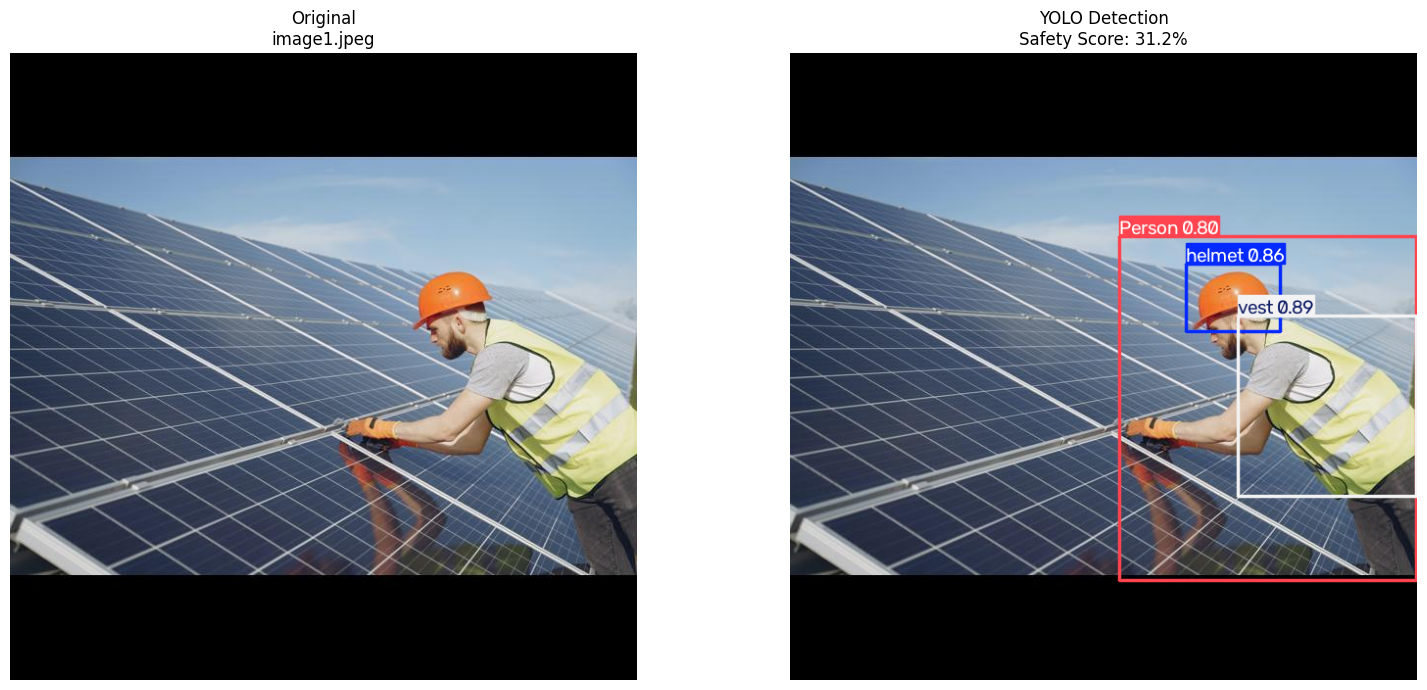


STEP 6C.2 COMPLETE

✓ Real test image processed
✓ YOLO inference completed
✓ Safety Rule Engine executed
✓ Safety analytics generated
✓ Annotated visualization generated


In [9]:
# ============================================================
# SafeVision AI — STEP 6C.2
# Real YOLO + Safety Rule Engine Test
# ============================================================

from pathlib import Path
import json
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO


# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = Path("/content/safevision_ai")

MODEL_PATH = PROJECT_DIR / "runs/yolo11n_ppe/weights/best.pt"
RULES_PATH = PROJECT_DIR / "src/safety_rules_config.json"
TEST_DIR = PROJECT_DIR / "datasets/images/test"


# ============================================================
# VALIDATION
# ============================================================

for required_path in [
    MODEL_PATH,
    RULES_PATH,
    TEST_DIR,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required path not found:\n{required_path}"
        )


# ============================================================
# LOAD MODEL
# ============================================================

print("=" * 70)
print("SafeVision AI — Real Test Image Inference")
print("=" * 70)

print("\nLoading YOLO model...")

model = YOLO(str(MODEL_PATH))

print("✓ Model loaded")


# ============================================================
# LOAD SAFETY RULES
# ============================================================

with open(RULES_PATH, "r") as f:
    SAFETY_RULES = json.load(f)

engine = SafetyRuleEngine(SAFETY_RULES)

print("✓ Safety Rule Engine loaded")


# ============================================================
# FIND TEST IMAGES
# ============================================================

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}

image_files = sorted(
    [
        p
        for p in TEST_DIR.iterdir()
        if p.is_file()
        and p.suffix.lower() in image_extensions
    ]
)

if not image_files:
    raise RuntimeError(
        f"No test images found in:\n{TEST_DIR}"
    )

print(f"✓ Test images found: {len(image_files)}")


# ============================================================
# SELECT TEST IMAGE
# ============================================================

IMAGE_PATH = image_files[0]

print(f"\nSelected test image:")
print(f"  {IMAGE_PATH.name}")


# ============================================================
# YOLO INFERENCE
# ============================================================

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45

print("\nRunning YOLO inference...")

results = model.predict(
    source=str(IMAGE_PATH),
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    verbose=False,
)

result = results[0]

print("✓ Inference complete")


# ============================================================
# EXTRACT DETECTIONS
# ============================================================

detections = []

if result.boxes is not None:

    for box in result.boxes:

        class_id = int(box.cls[0].item())
        confidence = float(box.conf[0].item())

        class_name = result.names[class_id]

        detections.append(
            {
                "class_name": class_name,
                "confidence": confidence,
            }
        )


# ============================================================
# SAFETY ANALYSIS
# ============================================================

analysis = engine.analyze(detections)


# ============================================================
# PRINT DETECTIONS
# ============================================================

print("\n" + "=" * 70)
print("YOLO DETECTIONS")
print("=" * 70)

if detections:

    for i, detection in enumerate(
        detections,
        start=1
    ):

        print(
            f"{i:02d}. "
            f"{detection['class_name']:<15} "
            f"confidence="
            f"{detection['confidence']:.3f}"
        )

else:

    print(
        "No detections above "
        f"confidence threshold ({CONF_THRESHOLD})."
    )


# ============================================================
# SAFETY ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("SAFETY ANALYSIS")
print("=" * 70)

print(
    f"\nTotal detections : "
    f"{analysis['total_detections']}"
)

print(
    f"Violations       : "
    f"{analysis['violation_count']}"
)

print(
    f"Safety Score     : "
    f"{analysis['safety_score']:.2f}%"
)


# ============================================================
# PPE COMPLIANCE
# ============================================================

print("\nPPE Compliance:")

for requirement, compliance in analysis[
    "compliance"
].items():

    if compliance is None:

        print(
            f"  • {requirement:<10} "
            f"N/A"
        )

    else:

        print(
            f"  • {requirement:<10} "
            f"{compliance:.2f}%"
        )


# ============================================================
# CONFIRMED VIOLATIONS
# ============================================================

print("\nConfirmed Violations:")

if analysis["violations"]:

    for violation in analysis["violations"]:

        print(
            f"  • {violation['category']} "
            f"→ {violation['class_name']} "
            f"({violation['confidence']:.3f})"
        )

else:

    print("  None")


# ============================================================
# LOAD ORIGINAL IMAGE
# ============================================================

original = cv2.imread(
    str(IMAGE_PATH)
)

if original is None:
    raise RuntimeError(
        f"Could not read image:\n{IMAGE_PATH}"
    )

original_rgb = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)


# ============================================================
# CREATE ANNOTATED IMAGE
# ============================================================

annotated = result.plot()

annotated_rgb = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)


# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)

plt.imshow(original_rgb)
plt.title(
    f"Original\n{IMAGE_PATH.name}"
)
plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(annotated_rgb)

plt.title(
    f"YOLO Detection\n"
    f"Safety Score: "
    f"{analysis['safety_score']:.1f}%"
)

plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("STEP 6C.2 COMPLETE")
print("=" * 70)

print("\n✓ Real test image processed")
print("✓ YOLO inference completed")
print("✓ Safety Rule Engine executed")
print("✓ Safety analytics generated")
print("✓ Annotated visualization generated")

In [10]:
# ============================================================
# SafeVision AI — STEP 6D
# Improved Safety Rule Engine
# ============================================================

from pathlib import Path
import json
from typing import Dict, List, Any


PROJECT_DIR = Path("/content/safevision_ai")
RULES_PATH = PROJECT_DIR / "src/safety_rules_config.json"


# ============================================================
# LOAD RULES
# ============================================================

with open(RULES_PATH, "r") as f:
    SAFETY_RULES = json.load(f)


# ============================================================
# SAFETY RULE ENGINE
# ============================================================

class SafetyRuleEngine:
    """
    Safety analytics layer built on top of YOLO detections.

    Design principles:
    1. Explicit negative classes are confirmed violations.
    2. Positive classes are confirmed PPE detections.
    3. Missing positive detections are NOT automatically violations.
    4. Requirements without an explicit negative class are not
       directly measurable for compliance.
    """

    def __init__(self, rules: Dict[str, Dict[str, Any]]):
        self.rules = rules

    # --------------------------------------------------------
    # Analyze detections
    # --------------------------------------------------------

    def analyze(
        self,
        detections: List[Dict[str, Any]]
    ) -> Dict[str, Any]:

        result = {
            "total_detections": len(detections),

            "ppe_detected": {},

            "violations": [],

            "violation_count": 0,

            "compliance": {},

            "measurable_requirements": [],

            "unmeasurable_requirements": [],

            "measurable_weight": 0.0,

            "safety_score": None,

            "score_status": "insufficient_evidence",
        }

        # ====================================================
        # Analyze every configured PPE requirement
        # ====================================================

        for requirement, rule in self.rules.items():

            positive_class = rule["positive_class"]
            violation_class = rule["violation_class"]

            positive_count = 0
            violation_count = 0

            # ------------------------------------------------
            # Inspect YOLO detections
            # ------------------------------------------------

            for detection in detections:

                class_name = detection.get(
                    "class_name"
                )

                confidence = float(
                    detection.get(
                        "confidence",
                        0.0
                    )
                )

                # Positive PPE
                if class_name == positive_class:
                    positive_count += 1

                # Explicit violation
                if (
                    violation_class is not None
                    and class_name == violation_class
                ):

                    violation_count += 1

                    result["violations"].append(
                        {
                            "requirement": requirement,
                            "category": rule["category"],
                            "class_name": class_name,
                            "confidence": confidence,
                            "type": "explicit_violation",
                        }
                    )

            # ------------------------------------------------
            # Store PPE information
            # ------------------------------------------------

            result["ppe_detected"][requirement] = {
                "positive_class": positive_class,
                "positive_count": positive_count,
                "violation_class": violation_class,
                "violation_count": violation_count,
            }

            # =================================================
            # Compliance calculation
            # =================================================

            # Requirements with explicit negative classes
            # are measurable.
            if violation_class is not None:

                total_observed = (
                    positive_count
                    + violation_count
                )

                if total_observed > 0:

                    compliance = (
                        positive_count
                        / total_observed
                    ) * 100.0

                    result[
                        "measurable_requirements"
                    ].append(requirement)

                    result[
                        "measurable_weight"
                    ] += float(rule["weight"])

                else:

                    # No positive OR negative evidence.
                    compliance = None

            # No negative class available.
            else:

                compliance = None

                result[
                    "unmeasurable_requirements"
                ].append(requirement)

            result[
                "compliance"
            ][requirement] = (
                round(compliance, 2)
                if compliance is not None
                else None
            )

        # ====================================================
        # Calculate Safety Score
        # ====================================================

        weighted_score = 0.0

        for requirement in result[
            "measurable_requirements"
        ]:

            rule = self.rules[requirement]

            compliance = result[
                "compliance"
            ][requirement]

            weighted_score += (
                compliance / 100.0
            ) * float(rule["weight"])

        measurable_weight = result[
            "measurable_weight"
        ]

        if measurable_weight > 0:

            result["safety_score"] = round(
                (
                    weighted_score
                    / measurable_weight
                ) * 100.0,
                2
            )

            result[
                "score_status"
            ] = "measurable"

        else:

            result["safety_score"] = None

            result[
                "score_status"
            ] = "insufficient_evidence"

        # ====================================================
        # Violation count
        # ====================================================

        result[
            "violation_count"
        ] = len(
            result["violations"]
        )

        return result


# ============================================================
# CREATE ENGINE
# ============================================================

engine = SafetyRuleEngine(
    SAFETY_RULES
)


# ============================================================
# TEST 1 — Helmet Only
# ============================================================

test_detections_1 = [
    {
        "class_name": "helmet",
        "confidence": 0.94
    }
]

result_1 = engine.analyze(
    test_detections_1
)


# ============================================================
# TEST 2 — Explicit Violations
# ============================================================

test_detections_2 = [
    {
        "class_name": "helmet",
        "confidence": 0.94
    },
    {
        "class_name": "no_helmet",
        "confidence": 0.88
    },
    {
        "class_name": "gloves",
        "confidence": 0.91
    },
    {
        "class_name": "no_gloves",
        "confidence": 0.82
    },
]


result_2 = engine.analyze(
    test_detections_2
)


# ============================================================
# DISPLAY TEST RESULTS
# ============================================================

print("=" * 70)
print("SafeVision AI — Improved Safety Rule Engine")
print("=" * 70)


print("\nTEST 1 — Helmet Detection Only")

print(
    f"Safety Score : "
    f"{result_1['safety_score']}"
)

print(
    f"Score Status : "
    f"{result_1['score_status']}"
)

print(
    f"Violations   : "
    f"{result_1['violation_count']}"
)

print("\nCompliance:")

for requirement, compliance in result_1[
    "compliance"
].items():

    if compliance is None:
        print(
            f"  • {requirement:<10} N/A"
        )
    else:
        print(
            f"  • {requirement:<10} "
            f"{compliance:.2f}%"
        )


print("\n" + "-" * 70)

print("\nTEST 2 — Explicit PPE Violations")

print(
    f"Safety Score : "
    f"{result_2['safety_score']:.2f}%"
)

print(
    f"Score Status : "
    f"{result_2['score_status']}"
)

print(
    f"Violations   : "
    f"{result_2['violation_count']}"
)

print("\nCompliance:")

for requirement, compliance in result_2[
    "compliance"
].items():

    if compliance is None:
        print(
            f"  • {requirement:<10} N/A"
        )
    else:
        print(
            f"  • {requirement:<10} "
            f"{compliance:.2f}%"
        )


print("\n" + "=" * 70)
print("STEP 6D COMPLETE")
print("=" * 70)

SafeVision AI — Improved Safety Rule Engine

TEST 1 — Helmet Detection Only
Safety Score : 100.0
Score Status : measurable
Violations   : 0

Compliance:
  • helmet     100.00%
  • goggles    N/A
  • gloves     N/A
  • boots      N/A
  • vest       N/A

----------------------------------------------------------------------

TEST 2 — Explicit PPE Violations
Safety Score : 50.00%
Score Status : measurable
Violations   : 2

Compliance:
  • helmet     50.00%
  • goggles    N/A
  • gloves     50.00%
  • boots      N/A
  • vest       N/A

STEP 6D COMPLETE


In [11]:
# ============================================================
# SafeVision AI — STEP 6E
# Batch Safety Evaluation on Test Set
# ============================================================

from pathlib import Path
from collections import Counter
import json
import numpy as np
from ultralytics import YOLO


# ============================================================
# CONFIGURATION
# ============================================================

PROJECT_DIR = Path("/content/safevision_ai")

MODEL_PATH = (
    PROJECT_DIR
    / "runs"
    / "yolo11n_ppe"
    / "weights"
    / "best.pt"
)

RULES_PATH = (
    PROJECT_DIR
    / "src"
    / "safety_rules_config.json"
)

TEST_DIR = (
    PROJECT_DIR
    / "datasets"
    / "images"
    / "test"
)

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45


# ============================================================
# VALIDATE PATHS
# ============================================================

print("=" * 70)
print("SafeVision AI — STEP 6E")
print("Batch Safety Evaluation")
print("=" * 70)

print("\nChecking project files...")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

if not RULES_PATH.exists():
    raise FileNotFoundError(
        f"Safety rules not found:\n{RULES_PATH}"
    )

if not TEST_DIR.exists():
    raise FileNotFoundError(
        f"Test directory not found:\n{TEST_DIR}"
    )

print("✓ Model found")
print("✓ Safety rules found")
print("✓ Test directory found")


# ============================================================
# LOAD SAFETY RULES
# ============================================================

with open(RULES_PATH, "r") as f:
    SAFETY_RULES = json.load(f)


# ============================================================
# RECREATE SAFETY RULE ENGINE
# ============================================================

class SafetyRuleEngine:
    """
    Detection-level safety analytics engine.

    Explicit negative classes are treated as confirmed
    violations.

    Missing PPE is NOT automatically considered a violation.
    """

    def __init__(self, rules):
        self.rules = rules

    def analyze(self, detections):

        result = {
            "total_detections": len(detections),
            "ppe_detected": {},
            "violations": [],
            "violation_count": 0,
            "compliance": {},
            "measurable_requirements": [],
            "unmeasurable_requirements": [],
            "measurable_weight": 0.0,
            "safety_score": None,
            "score_status": "insufficient_evidence",
        }

        # ----------------------------------------------------
        # Analyze requirements
        # ----------------------------------------------------

        for requirement, rule in self.rules.items():

            positive_class = rule["positive_class"]
            violation_class = rule["violation_class"]

            positive_count = 0
            violation_count = 0

            for detection in detections:

                class_name = detection.get("class_name")

                confidence = float(
                    detection.get("confidence", 0.0)
                )

                # Positive PPE detection
                if class_name == positive_class:
                    positive_count += 1

                # Explicit violation
                if (
                    violation_class is not None
                    and class_name == violation_class
                ):
                    violation_count += 1

                    result["violations"].append(
                        {
                            "requirement": requirement,
                            "category": rule["category"],
                            "class_name": class_name,
                            "confidence": confidence,
                            "type": "explicit_violation",
                        }
                    )

            # ------------------------------------------------
            # Store detection information
            # ------------------------------------------------

            result["ppe_detected"][requirement] = {
                "positive_class": positive_class,
                "positive_count": positive_count,
                "violation_class": violation_class,
                "violation_count": violation_count,
            }

            # ------------------------------------------------
            # Compliance
            # ------------------------------------------------

            if violation_class is not None:

                total_observed = (
                    positive_count
                    + violation_count
                )

                if total_observed > 0:

                    compliance = (
                        positive_count
                        / total_observed
                    ) * 100.0

                    result[
                        "measurable_requirements"
                    ].append(requirement)

                    result[
                        "measurable_weight"
                    ] += float(rule["weight"])

                else:
                    compliance = None

            else:

                compliance = None

                result[
                    "unmeasurable_requirements"
                ].append(requirement)

            result["compliance"][requirement] = (
                round(compliance, 2)
                if compliance is not None
                else None
            )

        # ----------------------------------------------------
        # Safety Score
        # ----------------------------------------------------

        weighted_score = 0.0

        for requirement in result[
            "measurable_requirements"
        ]:

            rule = self.rules[requirement]

            compliance = result[
                "compliance"
            ][requirement]

            weighted_score += (
                compliance / 100.0
            ) * float(rule["weight"])

        measurable_weight = result[
            "measurable_weight"
        ]

        if measurable_weight > 0:

            result["safety_score"] = round(
                (
                    weighted_score
                    / measurable_weight
                ) * 100.0,
                2
            )

            result[
                "score_status"
            ] = "measurable"

        # ----------------------------------------------------
        # Violation count
        # ----------------------------------------------------

        result["violation_count"] = len(
            result["violations"]
        )

        return result


# ============================================================
# INITIALIZE MODEL + ENGINE
# ============================================================

print("\nLoading YOLO model...")

model = YOLO(str(MODEL_PATH))

engine = SafetyRuleEngine(
    SAFETY_RULES
)

print("✓ YOLO model loaded")
print("✓ Safety Rule Engine initialized")


# ============================================================
# GET TEST IMAGES
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

test_images = sorted(
    [
        p
        for p in TEST_DIR.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]
)

if not test_images:
    raise RuntimeError(
        f"No test images found in:\n{TEST_DIR}"
    )

print(
    f"\n✓ Test images found: {len(test_images)}"
)


# ============================================================
# BATCH EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("Running batch safety evaluation...")
print("=" * 70)

images_analyzed = 0
images_with_ppe = 0
images_with_violations = 0
images_insufficient_evidence = 0

safety_scores = []

violation_image_counts = Counter()
violation_detection_counts = Counter()

all_detection_counts = Counter()

image_results = []


# ============================================================
# PROCESS EACH IMAGE
# ============================================================

for image_path in test_images:

    try:

        # ----------------------------------------------------
        # YOLO inference
        # ----------------------------------------------------

        prediction = model.predict(
            source=str(image_path),
            conf=CONF_THRESHOLD,
            iou=IOU_THRESHOLD,
            verbose=False
        )[0]

        detections = []

        # ----------------------------------------------------
        # Extract detections
        # ----------------------------------------------------

        if prediction.boxes is not None:

            for box in prediction.boxes:

                class_id = int(
                    box.cls[0].item()
                )

                confidence = float(
                    box.conf[0].item()
                )

                class_name = model.names[
                    class_id
                ]

                detections.append(
                    {
                        "class_name": class_name,
                        "confidence": confidence,
                    }
                )

                all_detection_counts[
                    class_name
                ] += 1

        # ----------------------------------------------------
        # Safety analysis
        # ----------------------------------------------------

        analysis = engine.analyze(
            detections
        )

        images_analyzed += 1

        # ----------------------------------------------------
        # PPE detection
        # ----------------------------------------------------

        if len(detections) > 0:
            images_with_ppe += 1

        # ----------------------------------------------------
        # Violations
        # ----------------------------------------------------

        if analysis[
            "violation_count"
        ] > 0:

            images_with_violations += 1

            violation_types_in_image = set()

            for violation in analysis[
                "violations"
            ]:

                requirement = (
                    violation["requirement"]
                )

                violation_class = (
                    violation["class_name"]
                )

                violation_image_counts[
                    requirement
                ] += 1

                violation_detection_counts[
                    violation_class
                ] += 1

                violation_types_in_image.add(
                    requirement
                )

        # ----------------------------------------------------
        # Safety Score
        # ----------------------------------------------------

        if (
            analysis["safety_score"]
            is not None
        ):

            safety_scores.append(
                analysis["safety_score"]
            )

        else:

            images_insufficient_evidence += 1

        # ----------------------------------------------------
        # Store image-level result
        # ----------------------------------------------------

        image_results.append(
            {
                "image": image_path.name,
                "detections": len(detections),
                "violations": analysis[
                    "violation_count"
                ],
                "safety_score": analysis[
                    "safety_score"
                ],
                "score_status": analysis[
                    "score_status"
                ],
            }
        )

    except Exception as e:

        print(
            f"\n⚠️ Error processing "
            f"{image_path.name}: {e}"
        )


# ============================================================
# CALCULATE FINAL STATISTICS
# ============================================================

average_safety_score = (
    float(np.mean(safety_scores))
    if safety_scores
    else None
)

ppe_detection_rate = (
    (
        images_with_ppe
        / images_analyzed
    ) * 100.0
    if images_analyzed > 0
    else 0.0
)

violation_image_rate = (
    (
        images_with_violations
        / images_analyzed
    ) * 100.0
    if images_analyzed > 0
    else 0.0
)

insufficient_evidence_rate = (
    (
        images_insufficient_evidence
        / images_analyzed
    ) * 100.0
    if images_analyzed > 0
    else 0.0
)


# ============================================================
# DISPLAY FINAL RESULTS
# ============================================================

print("\n\n" + "=" * 70)
print("SafeVision AI — Batch Safety Evaluation Results")
print("=" * 70)

print(
    f"\nImages analyzed              : "
    f"{images_analyzed}"
)

print(
    f"Images with PPE detections   : "
    f"{images_with_ppe}"
)

print(
    f"PPE detection image rate     : "
    f"{ppe_detection_rate:.2f}%"
)

print(
    f"Images with violations       : "
    f"{images_with_violations}"
)

print(
    f"Violation image rate         : "
    f"{violation_image_rate:.2f}%"
)

print(
    f"Insufficient evidence images : "
    f"{images_insufficient_evidence}"
)

print(
    f"Insufficient evidence rate   : "
    f"{insufficient_evidence_rate:.2f}%"
)


# ============================================================
# AVERAGE SAFETY SCORE
# ============================================================

print("\nAverage Measurable Safety Score:")

if average_safety_score is not None:

    print(
        f"  {average_safety_score:.2f}%"
    )

else:

    print(
        "  N/A — no measurable images"
    )


print("\n" + "-" * 70)
print("Explicit Violation Frequency")
print("-" * 70)


# ============================================================
# VIOLATION FREQUENCIES
# ============================================================

requirements_to_report = [
    ("helmet", "no_helmet"),
    ("gloves", "no_gloves"),
    ("boots", "no_boots"),
    ("goggles", "no_goggle"),
]

for requirement, violation_class in (
    requirements_to_report
):

    image_count = (
        violation_image_counts[
            requirement
        ]
    )

    detection_count = (
        violation_detection_counts[
            violation_class
        ]
    )

    print(
        f"\n{requirement.capitalize():<10}"
    )

    print(
        f"  Images with violation : "
        f"{image_count}"
    )

    print(
        f"  Violation detections  : "
        f"{detection_count}"
    )

    if images_analyzed > 0:

        frequency = (
            image_count
            / images_analyzed
        ) * 100.0

        print(
            f"  Image frequency       : "
            f"{frequency:.2f}%"
        )


# ============================================================
# DETECTION DISTRIBUTION
# ============================================================

print("\n" + "-" * 70)
print("Detected Class Distribution")
print("-" * 70)

if all_detection_counts:

    for class_name, count in (
        all_detection_counts.most_common()
    ):

        print(
            f"  {class_name:<20} "
            f"{count}"
        )

else:

    print("  No detections found.")


# ============================================================
# SAVE RESULTS
# ============================================================

EVALUATION_DIR = (
    PROJECT_DIR
    / "evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_PATH = (
    EVALUATION_DIR
    / "batch_safety_results.json"
)

summary = {
    "model": str(MODEL_PATH),
    "test_directory": str(TEST_DIR),
    "confidence_threshold": CONF_THRESHOLD,
    "iou_threshold": IOU_THRESHOLD,

    "images_analyzed": images_analyzed,
    "images_with_ppe": images_with_ppe,
    "ppe_detection_rate": round(
        ppe_detection_rate,
        2
    ),

    "images_with_violations":
        images_with_violations,

    "violation_image_rate":
        round(
            violation_image_rate,
            2
        ),

    "images_insufficient_evidence":
        images_insufficient_evidence,

    "insufficient_evidence_rate":
        round(
            insufficient_evidence_rate,
            2
        ),

    "average_measurable_safety_score":
        round(
            average_safety_score,
            2
        )
        if average_safety_score is not None
        else None,

    "violation_image_counts":
        dict(
            violation_image_counts
        ),

    "violation_detection_counts":
        dict(
            violation_detection_counts
        ),

    "all_detection_counts":
        dict(
            all_detection_counts
        ),

    "image_results": image_results,
}


with open(
    RESULTS_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("STEP 6E COMPLETE")
print("=" * 70)

print(
    f"\n✓ Batch evaluation completed"
)

print(
    f"✓ Results saved to:"
)

print(
    f"  {RESULTS_PATH}"
)

print(
    "\n✓ No fabricated statistics — "
    "all values above come from actual "
    "YOLO inference on the test set."
)

print("=" * 70)

SafeVision AI — STEP 6E
Batch Safety Evaluation

Checking project files...
✓ Model found
✓ Safety rules found
✓ Test directory found

Loading YOLO model...
✓ YOLO model loaded
✓ Safety Rule Engine initialized

✓ Test images found: 141

Running batch safety evaluation...


SafeVision AI — Batch Safety Evaluation Results

Images analyzed              : 141
Images with PPE detections   : 141
PPE detection image rate     : 100.00%
Images with violations       : 22
Violation image rate         : 15.60%
Insufficient evidence images : 4
Insufficient evidence rate   : 2.84%

Average Measurable Safety Score:
  84.43%

----------------------------------------------------------------------
Explicit Violation Frequency
----------------------------------------------------------------------

Helmet    
  Images with violation : 28
  Violation detections  : 28
  Image frequency       : 19.86%

Gloves    
  Images with violation : 16
  Violation detections  : 16
  Image frequency       : 11.35%

Boots

In [12]:
# ============================================================
# SafeVision AI — STEP 6F
# Professional Image Inference Pipeline
# ============================================================

from pathlib import Path
from typing import Dict, List, Any
import json

from ultralytics import YOLO


# ============================================================
# CONFIGURATION
# ============================================================

PROJECT_DIR = Path("/content/safevision_ai")

MODEL_PATH = (
    PROJECT_DIR
    / "runs"
    / "yolo11n_ppe"
    / "weights"
    / "best.pt"
)

RULES_PATH = (
    PROJECT_DIR
    / "src"
    / "safety_rules_config.json"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "evaluation"
    / "image_inference"
)

CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45


# ============================================================
# VALIDATE FILES
# ============================================================

print("=" * 70)
print("SafeVision AI — STEP 6F")
print("Professional Image Inference Pipeline")
print("=" * 70)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

if not RULES_PATH.exists():
    raise FileNotFoundError(
        f"Safety rules not found:\n{RULES_PATH}"
    )

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\n✓ Model found")
print("✓ Safety rules found")
print("✓ Output directory ready")


# ============================================================
# LOAD MODEL + RULES
# ============================================================

print("\nLoading YOLO model...")

model = YOLO(
    str(MODEL_PATH)
)

with open(
    RULES_PATH,
    "r"
) as f:

    SAFETY_RULES = json.load(f)

print("✓ YOLO model loaded")
print("✓ Safety rules loaded")


# ============================================================
# SAFETY RULE ENGINE
# ============================================================

class SafetyRuleEngine:

    def __init__(
        self,
        rules: Dict[str, Dict[str, Any]]
    ):
        self.rules = rules

    def analyze(
        self,
        detections: List[Dict[str, Any]]
    ) -> Dict[str, Any]:

        result = {
            "total_detections": len(detections),
            "ppe_detected": {},
            "violations": [],
            "violation_count": 0,
            "compliance": {},
            "measurable_requirements": [],
            "unmeasurable_requirements": [],
            "measurable_weight": 0.0,
            "safety_score": None,
            "score_status": "insufficient_evidence",
        }

        # ----------------------------------------------------
        # Analyze each requirement
        # ----------------------------------------------------

        for requirement, rule in self.rules.items():

            positive_class = rule[
                "positive_class"
            ]

            violation_class = rule[
                "violation_class"
            ]

            positive_count = 0
            violation_count = 0

            # ------------------------------------------------
            # Inspect detections
            # ------------------------------------------------

            for detection in detections:

                class_name = detection.get(
                    "class_name"
                )

                confidence = float(
                    detection.get(
                        "confidence",
                        0.0
                    )
                )

                # Positive PPE
                if class_name == positive_class:

                    positive_count += 1

                # Explicit violation
                if (
                    violation_class is not None
                    and class_name == violation_class
                ):

                    violation_count += 1

                    result[
                        "violations"
                    ].append(
                        {
                            "requirement":
                                requirement,

                            "category":
                                rule["category"],

                            "class_name":
                                class_name,

                            "confidence":
                                confidence,

                            "type":
                                "explicit_violation",
                        }
                    )

            # ------------------------------------------------
            # Store PPE information
            # ------------------------------------------------

            result[
                "ppe_detected"
            ][requirement] = {

                "positive_class":
                    positive_class,

                "positive_count":
                    positive_count,

                "violation_class":
                    violation_class,

                "violation_count":
                    violation_count,
            }

            # ------------------------------------------------
            # Compliance
            # ------------------------------------------------

            if violation_class is not None:

                total_observed = (
                    positive_count
                    + violation_count
                )

                if total_observed > 0:

                    compliance = (
                        positive_count
                        / total_observed
                    ) * 100.0

                    result[
                        "measurable_requirements"
                    ].append(
                        requirement
                    )

                    result[
                        "measurable_weight"
                    ] += float(
                        rule["weight"]
                    )

                else:

                    compliance = None

            else:

                compliance = None

                result[
                    "unmeasurable_requirements"
                ].append(
                    requirement
                )

            result[
                "compliance"
            ][requirement] = (

                round(
                    compliance,
                    2
                )

                if compliance is not None

                else None
            )

        # ----------------------------------------------------
        # Calculate safety score
        # ----------------------------------------------------

        weighted_score = 0.0

        for requirement in result[
            "measurable_requirements"
        ]:

            rule = self.rules[
                requirement
            ]

            compliance = result[
                "compliance"
            ][requirement]

            weighted_score += (
                compliance / 100.0
            ) * float(
                rule["weight"]
            )

        measurable_weight = result[
            "measurable_weight"
        ]

        if measurable_weight > 0:

            result[
                "safety_score"
            ] = round(
                (
                    weighted_score
                    / measurable_weight
                ) * 100.0,
                2
            )

            result[
                "score_status"
            ] = "measurable"

        result[
            "violation_count"
        ] = len(
            result["violations"]
        )

        return result


# ============================================================
# INITIALIZE ENGINE
# ============================================================

engine = SafetyRuleEngine(
    SAFETY_RULES
)


# ============================================================
# IMAGE INFERENCE FUNCTION
# ============================================================

def run_image_inference(
    image_path: str | Path,
    conf_threshold: float = CONF_THRESHOLD,
    iou_threshold: float = IOU_THRESHOLD,
):
    """
    Run YOLO detection + Safety Rule Engine
    on a single image.
    """

    image_path = Path(
        image_path
    )

    if not image_path.exists():

        raise FileNotFoundError(
            f"Image not found:\n{image_path}"
        )

    # --------------------------------------------------------
    # YOLO inference
    # --------------------------------------------------------

    prediction = model.predict(
        source=str(image_path),
        conf=conf_threshold,
        iou=iou_threshold,
        verbose=False
    )[0]

    detections = []

    # --------------------------------------------------------
    # Extract detections
    # --------------------------------------------------------

    if prediction.boxes is not None:

        for box in prediction.boxes:

            class_id = int(
                box.cls[0].item()
            )

            confidence = float(
                box.conf[0].item()
            )

            class_name = model.names[
                class_id
            ]

            detections.append(
                {
                    "class_name":
                        class_name,

                    "confidence":
                        confidence,

                    "class_id":
                        class_id,
                }
            )

    # --------------------------------------------------------
    # Safety analysis
    # --------------------------------------------------------

    safety_analysis = engine.analyze(
        detections
    )

    # --------------------------------------------------------
    # Save annotated image
    # --------------------------------------------------------

    annotated_image = prediction.plot()

    output_path = (
        OUTPUT_DIR
        / f"{image_path.stem}_annotated.jpg"
    )

    import cv2

    cv2.imwrite(
        str(output_path),
        annotated_image
    )

    # --------------------------------------------------------
    # Return structured result
    # --------------------------------------------------------

    return {
        "image": str(image_path),
        "detections": detections,
        "safety_analysis": safety_analysis,
        "annotated_image": str(
            output_path
        ),
    }


# ============================================================
# SELECT REAL TEST IMAGE
# ============================================================

TEST_DIR = (
    PROJECT_DIR
    / "datasets"
    / "images"
    / "test"
)

test_images = sorted(
    [
        p
        for p in TEST_DIR.iterdir()
        if p.suffix.lower()
        in {
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp",
        }
    ]
)

if not test_images:

    raise RuntimeError(
        "No test images found."
    )

# Use the first real test image.
TEST_IMAGE = test_images[0]


# ============================================================
# RUN PIPELINE
# ============================================================

print("\n" + "=" * 70)
print("Running image inference...")
print("=" * 70)

print(
    f"\nInput image:\n{TEST_IMAGE}"
)

result = run_image_inference(
    TEST_IMAGE
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

analysis = result[
    "safety_analysis"
]

detections = result[
    "detections"
]


print("\n" + "=" * 70)
print("Inference Results")
print("=" * 70)

print(
    f"\nTotal detections : "
    f"{len(detections)}"
)


# ------------------------------------------------------------
# Detection list
# ------------------------------------------------------------

print("\nDetections:")

if detections:

    for detection in detections:

        print(
            f"  • "
            f"{detection['class_name']:<15}"
            f" "
            f"{detection['confidence']:.3f}"
        )

else:

    print(
        "  No objects detected."
    )


# ------------------------------------------------------------
# Safety score
# ------------------------------------------------------------

print("\nSafety Analytics:")

if analysis[
    "safety_score"
] is not None:

    print(
        f"  Safety Score : "
        f"{analysis['safety_score']:.2f}%"
    )

else:

    print(
        "  Safety Score : N/A"
    )

print(
    f"  Score Status : "
    f"{analysis['score_status']}"
)

print(
    f"  Violations   : "
    f"{analysis['violation_count']}"
)


# ------------------------------------------------------------
# Compliance
# ------------------------------------------------------------

print("\nPPE Compliance:")

for requirement, compliance in (
    analysis["compliance"].items()
):

    if compliance is None:

        print(
            f"  • "
            f"{requirement:<10}"
            f" N/A"
        )

    else:

        print(
            f"  • "
            f"{requirement:<10}"
            f" "
            f"{compliance:.2f}%"
        )


# ------------------------------------------------------------
# Violations
# ------------------------------------------------------------

print("\nConfirmed Violations:")

if analysis[
    "violations"
]:

    for violation in analysis[
        "violations"
    ]:

        print(
            f"  ⚠ "
            f"{violation['category']}"
            f" → "
            f"{violation['class_name']}"
            f" "
            f"({violation['confidence']:.3f})"
        )

else:

    print(
        "  None"
    )


# ============================================================
# OUTPUT
# ============================================================

print("\n" + "=" * 70)

print(
    "Annotated image saved to:"
)

print(
    result[
        "annotated_image"
    ]
)

print("=" * 70)

print(
    "\nSTEP 6F COMPLETE"
)

print(
    "✓ Real YOLO inference"
)

print(
    "✓ Safety Rule Engine integration"
)

print(
    "✓ Structured safety analytics"
)

print(
    "✓ Annotated image generated"
)

print("=" * 70)

SafeVision AI — STEP 6F
Professional Image Inference Pipeline

✓ Model found
✓ Safety rules found
✓ Output directory ready

Loading YOLO model...
✓ YOLO model loaded
✓ Safety rules loaded

Running image inference...

Input image:
/content/safevision_ai/datasets/images/test/image1.jpeg

Inference Results

Total detections : 3

Detections:
  • vest            0.887
  • helmet          0.864
  • Person          0.801

Safety Analytics:
  Safety Score : 100.00%
  Score Status : measurable
  Violations   : 0

PPE Compliance:
  • helmet     100.00%
  • goggles    N/A
  • gloves     N/A
  • boots      N/A
  • vest       N/A

Confirmed Violations:
  None

Annotated image saved to:
/content/safevision_ai/evaluation/image_inference/image1_annotated.jpg

STEP 6F COMPLETE
✓ Real YOLO inference
✓ Safety Rule Engine integration
✓ Structured safety analytics
✓ Annotated image generated


In [13]:
# ============================================================
# SafeVision AI — Export Production Artifacts
# ============================================================

from pathlib import Path
from google.colab import files
import shutil

PROJECT_DIR = Path("/content/safevision_ai")

FILES_TO_EXPORT = [
    PROJECT_DIR / "runs/yolo11n_ppe/weights/best.pt",
    PROJECT_DIR / "src/safety_rules_config.json",
    PROJECT_DIR / "evaluation/batch_safety_results.json",
]

print("=" * 70)
print("SafeVision AI — Export Artifacts")
print("=" * 70)

for path in FILES_TO_EXPORT:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    print(f"✓ {path}")

# Create a single ZIP for easy transfer
EXPORT_DIR = PROJECT_DIR / "production_export"
EXPORT_DIR.mkdir(exist_ok=True)

# Clean previous export
for item in EXPORT_DIR.iterdir():
    if item.is_file():
        item.unlink()
    elif item.is_dir():
        shutil.rmtree(item)

# Copy files while preserving simple structure
shutil.copy2(
    PROJECT_DIR / "runs/yolo11n_ppe/weights/best.pt",
    EXPORT_DIR / "best.pt"
)

shutil.copy2(
    PROJECT_DIR / "src/safety_rules_config.json",
    EXPORT_DIR / "safety_rules_config.json"
)

shutil.copy2(
    PROJECT_DIR / "evaluation/batch_safety_results.json",
    EXPORT_DIR / "batch_safety_results.json"
)

# ZIP
zip_path = shutil.make_archive(
    str(PROJECT_DIR / "SafeVision_AI_production"),
    "zip",
    root_dir=EXPORT_DIR
)

print("\n✓ Export package created:")
print(zip_path)

print("\n" + "=" * 70)
print("Download starting...")
print("=" * 70)

files.download(zip_path)

SafeVision AI — Export Artifacts
✓ /content/safevision_ai/runs/yolo11n_ppe/weights/best.pt
✓ /content/safevision_ai/src/safety_rules_config.json
✓ /content/safevision_ai/evaluation/batch_safety_results.json

✓ Export package created:
/content/safevision_ai/SafeVision_AI_production.zip

Download starting...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>